# MVP v0.2.5.13: Sigmoid Reward Model for Noise-Robust OPE

**Date:** 2026-03-25  
**Builds on:** v0.2.5.6 (cross-policy guidance with hard threshold reward)  

## Goal

Replace the hard binary reward (`cube_z > 0.84 → 1, else 0`) with a sigmoid reward  
to make OPE robust to diffusion noise in synthetic trajectories. Compare both reward  
models on the same 6-policy multi-policy evaluation from v0.2.5.6.

**Hypothesis:** The hard threshold is sensitive to noise around `cube_z ≈ 0.84`,  
randomly flipping rewards. A sigmoid smoothly transitions, so small errors in  
generated `cube_z` produce proportionally small errors in reward, improving  
Spearman rank correlation with oracle SR.

In [1]:
%matplotlib inline
import sys, os, importlib
import numpy as np
import torch
import torch.nn as nn
import h5py, json, math, time
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import stats

PROJECT_ROOT = Path("/home1/reishuen/latent_sope")
sys.path.insert(0, str(PROJECT_ROOT))
sys.path.insert(0, str(PROJECT_ROOT / "src"))
sys.path.insert(0, str(PROJECT_ROOT / "third_party" / "sope"))
sys.path.insert(0, str(PROJECT_ROOT / "third_party" / "robomimic"))

from opelab.core.baselines.diffusion.temporal import TemporalUnet
from opelab.core.baselines.diffusion.diffusion import GaussianDiffusion
from opelab.core.baselines.diffusion.helpers import EMA, apply_conditioning
import robomimic.utils.file_utils as FileUtils
import robomimic.utils.obs_utils as ObsUtils

import latent_sope.robomimic_interface.guidance as _guidance_mod
importlib.reload(_guidance_mod)
from latent_sope.robomimic_interface.checkpoints import (
    load_checkpoint, build_algo_from_checkpoint
)
from latent_sope.robomimic_interface.guidance import RobomimicDiffusionScorer

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# Paths
CKPT_BASE = PROJECT_ROOT / "third_party/robomimic/diffusion_policy_trained_models"
DEMO_HDF5 = PROJECT_ROOT / "third_party/robomimic/datasets/lift/ph/low_dim_v15.hdf5"
TARGET_ROLLOUT_DIR = PROJECT_ROOT / "rollouts" / "target_policy_50"
DIFFUSION_SAVE_DIR = PROJECT_ROOT / "diffusion_ckpts" / "mvp_v0252_traj_mse"
ORACLE_JSON = PROJECT_ROOT / "results/2026-03-12/oracle_eval_all_checkpoints.json"
OBS_KEYS = ["object", "robot0_eef_pos", "robot0_eef_quat", "robot0_gripper_qpos"]

# Dims
STATE_DIM = 19
ACTION_DIM = 7
TRANSITION_DIM = 26
CUBE_Z_INDEX = 2
LIFT_THRESHOLD = 0.84

# Diffuser config (must match v0.2.5.2 training)
CHUNK_SIZE = 4
N_DIFFUSION_STEPS = 256
BASE_DIM = 32
DIM_MULTS = (1, 4, 8)
ACTION_WEIGHT = 5.0

# Generation config
NUM_SYNTHETIC = 50
T_GEN = 60
GAMMA = 1.0

# Guidance config (best from v0.2.5.5)
SCORE_TIMESTEP = 5
ACTION_SCALE = 0.001

# Sigmoid reward config
SIGMOID_SHARPNESS = 150.0  # transition width ~±1.5cm around threshold

# Target policies to evaluate (same 6 as v0.2.5.6)
TARGET_POLICIES = [
    {"name": "10demos_epoch10",  "dir": "lift_diffusion_10demos/20260311115828",  "ckpt": "models/model_epoch_10.pth"},
    {"name": "100demos_epoch20", "dir": "lift_diffusion_100demos/20260311135551", "ckpt": "models/model_epoch_20.pth"},
    {"name": "test_checkpoint",  "dir": "test/20260309132349",                   "ckpt": "last.pth"},
    {"name": "10demos_epoch30",  "dir": "lift_diffusion_10demos/20260311115828",  "ckpt": "models/model_epoch_30.pth"},
    {"name": "50demos_epoch30",  "dir": "lift_diffusion_50demos/20260311134204",  "ckpt": "models/model_epoch_30.pth"},
    {"name": "200demos_epoch40", "dir": "lift_diffusion_200demos/20260311141036", "ckpt": "models/model_epoch_40.pth"},
]

print(f"score_timestep={SCORE_TIMESTEP}, action_scale={ACTION_SCALE}")
print(f"sigmoid_sharpness={SIGMOID_SHARPNESS}")
print(f"{NUM_SYNTHETIC} trajs, T_GEN={T_GEN}")
print(f"{len(TARGET_POLICIES)} target policies to evaluate")

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

CLIPTextModelWithProjection LOAD REPORT from: openai/clip-vit-large-patch14
Key                                                            | Status     |  | 
---------------------------------------------------------------+------------+--+-
vision_model.encoder.layers.{0...23}.layer_norm1.bias          | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.self_attn.out_proj.bias   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.mlp.fc1.bias              | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.self_attn.k_proj.weight   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.layer_norm2.weight        | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.mlp.fc1.weight            | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.self_attn.q_proj.bias     | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.mlp.fc2.bias              | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.self_attn.v_proj.weight   | UNEXPECTED |  | 
vision_model.encoder.l

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Device: cuda
score_timestep=5, action_scale=0.001
sigmoid_sharpness=150.0
50 trajs, T_GEN=60
6 target policies to evaluate


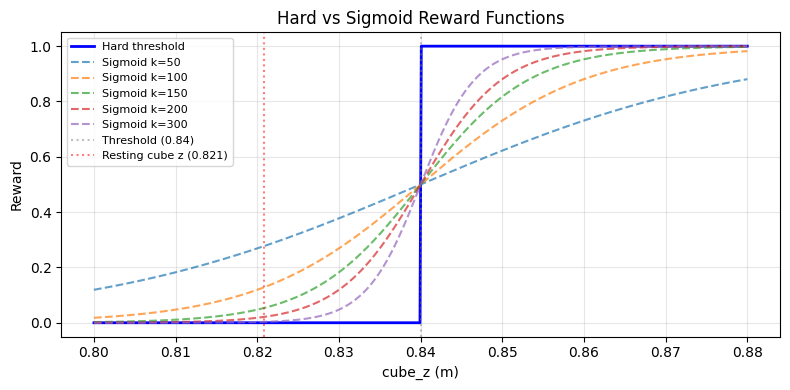

  cube_z=0.820  hard=0  sigmoid=0.0474
  cube_z=0.830  hard=0  sigmoid=0.1824
  cube_z=0.835  hard=0  sigmoid=0.3208
  cube_z=0.838  hard=0  sigmoid=0.4256
  cube_z=0.840  hard=0  sigmoid=0.5000
  cube_z=0.842  hard=1  sigmoid=0.5744
  cube_z=0.845  hard=1  sigmoid=0.6792
  cube_z=0.850  hard=1  sigmoid=0.8176


In [2]:
# ── Reward functions ──

def hard_reward(cube_z):
    """Binary reward: 1 if cube_z > 0.84, else 0."""
    return (cube_z > LIFT_THRESHOLD).astype(np.float32)

def sigmoid_reward(cube_z, center=LIFT_THRESHOLD, sharpness=SIGMOID_SHARPNESS):
    """Smooth sigmoid reward centered at the lift threshold."""
    return (1.0 / (1.0 + np.exp(-sharpness * (cube_z - center)))).astype(np.float32)

# ── Visualize reward functions ──
z_range = np.linspace(0.80, 0.88, 500)
fig, ax = plt.subplots(1, 1, figsize=(8, 4))
ax.plot(z_range, hard_reward(z_range), 'b-', linewidth=2, label='Hard threshold')
for sharpness in [50, 100, 150, 200, 300]:
    ax.plot(z_range, sigmoid_reward(z_range, sharpness=sharpness), '--',
            linewidth=1.5, alpha=0.7, label=f'Sigmoid k={sharpness}')
ax.axvline(LIFT_THRESHOLD, color='gray', linestyle=':', alpha=0.5, label=f'Threshold ({LIFT_THRESHOLD})')
ax.axvline(0.8208, color='red', linestyle=':', alpha=0.5, label='Resting cube z (0.821)')
ax.set_xlabel('cube_z (m)')
ax.set_ylabel('Reward')
ax.set_title('Hard vs Sigmoid Reward Functions')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Show key values
for z in [0.82, 0.83, 0.835, 0.838, 0.84, 0.842, 0.845, 0.85]:
    print(f"  cube_z={z:.3f}  hard={hard_reward(np.array([z]))[0]:.0f}  sigmoid={sigmoid_reward(np.array([z]))[0]:.4f}")

In [3]:
# ── OPE scoring functions ──

def compute_ope_hard(states, gamma=1.0):
    """OPE using hard binary reward (v0.2.5.6 method).
    Returns per-trajectory discounted return."""
    B, T, _ = states.shape
    cube_z = states[:, :, CUBE_Z_INDEX]  # (B, T)
    rewards = hard_reward(cube_z)  # (B, T)
    gammas = gamma ** np.arange(T)  # (T,)
    returns = (rewards * gammas[None, :]).sum(axis=1)  # (B,)
    return returns

def compute_ope_sigmoid(states, gamma=1.0):
    """OPE using sigmoid reward.
    Returns per-trajectory discounted return."""
    B, T, _ = states.shape
    cube_z = states[:, :, CUBE_Z_INDEX]  # (B, T)
    rewards = sigmoid_reward(cube_z)  # (B, T)
    gammas = gamma ** np.arange(T)  # (T,)
    returns = (rewards * gammas[None, :]).sum(axis=1)  # (B,)
    return returns

def compute_sr_hard(states):
    """Success rate: fraction of trajectories where any cube_z > threshold."""
    B = states.shape[0]
    cube_z = states[:, :, CUBE_Z_INDEX]
    return np.mean([np.any(cube_z[j] > LIFT_THRESHOLD) for j in range(B)])

print("OPE scoring functions defined.")

OPE scoring functions defined.


In [4]:
# ── Load oracle results ──
with open(ORACLE_JSON, "r") as f:
    oracle_all = json.load(f)

oracle_sr_map = {}
for pol in TARGET_POLICIES:
    name = pol["name"]
    if name == "test_checkpoint":
        with open(CKPT_BASE / "test/20260309132349/oracle_50.json", "r") as f:
            test_oracle = json.load(f)
        oracle_sr_map[name] = float(test_oracle["mean_return"])
    else:
        oracle_sr_map[name] = float(oracle_all[name]["mean_return"])

print("Oracle SR values:")
for name, sr in oracle_sr_map.items():
    print(f"  {name:<22} {sr*100:.0f}%")

Oracle SR values:
  10demos_epoch10        8%
  100demos_epoch20       42%
  test_checkpoint        54%
  10demos_epoch30        62%
  50demos_epoch30        82%
  200demos_epoch40       90%


In [5]:
# ── Load target rollouts (for initial states) and expert demos (for normalization) ──
target_data = []
all_states_list, all_actions_list = [], []
for path in sorted(TARGET_ROLLOUT_DIR.glob("rollout_*.h5"))[:50]:
    with h5py.File(path, "r") as f:
        latents = f["latents"][:]
        actions = f["actions"][:]
    states = (latents[:, -1, :] if latents.ndim == 3 else latents).astype(np.float32)
    actions = actions.astype(np.float32)
    target_data.append({"states": states, "actions": actions})
    all_states_list.append(states)
    all_actions_list.append(actions)
print(f"Loaded {len(target_data)} target rollouts")

# Expert demos
with h5py.File(DEMO_HDF5, "r") as f:
    for dk in sorted(f["data"].keys(), key=lambda x: int(x.split("_")[1])):
        demo = f[f"data/{dk}"]
        states = np.concatenate([demo["obs"][k][:].astype(np.float32) for k in OBS_KEYS], axis=-1)
        actions = demo["actions"][:].astype(np.float32)
        all_states_list.append(states)
        all_actions_list.append(actions)
print(f"Loaded 200 expert demos")

# Normalization (same as v0.2.5.2 training)
all_states = np.concatenate(all_states_list, axis=0)
all_actions = np.concatenate(all_actions_list, axis=0)
norm_mean = np.concatenate([all_states.mean(0), all_actions.mean(0)]).astype(np.float32)
norm_std = np.maximum(np.concatenate([all_states.std(0), all_actions.std(0)]), 1e-6).astype(np.float32)
norm_mean_t = torch.tensor(norm_mean, device=device)
norm_std_t = torch.tensor(norm_std, device=device)
normalize_fn = lambda x: (x - norm_mean_t) / norm_std_t
unnormalize_fn = lambda x: x * norm_std_t + norm_mean_t

# Initial states for generation
initial_states_t = torch.tensor(
    np.array([ep["states"][0] for ep in target_data[:NUM_SYNTHETIC]]),
    dtype=torch.float32, device=device
)
print(f"Initial states: {initial_states_t.shape}")

Loaded 50 target rollouts


Loaded 200 expert demos


Initial states: torch.Size([50, 19])


In [6]:
# ── Load pre-trained diffuser ──
temporal_model = TemporalUnet(
    horizon=CHUNK_SIZE, transition_dim=TRANSITION_DIM,
    dim=BASE_DIM, dim_mults=DIM_MULTS, attention=False,
).to(device)
diffusion_model = GaussianDiffusion(
    model=temporal_model, horizon=CHUNK_SIZE,
    observation_dim=STATE_DIM, action_dim=ACTION_DIM,
    n_timesteps=N_DIFFUSION_STEPS,
    normalizer=normalize_fn, unnormalizer=unnormalize_fn,
    predict_epsilon=False, loss_type="l2",
    clip_denoised=False, action_weight=ACTION_WEIGHT,
).to(device)
ema = EMA(diffusion_model)
ema.ema_model.load_state_dict(
    torch.load(DIFFUSION_SAVE_DIR / "diffusion_model_ema.pt", map_location=device)
)
print(f"Loaded EMA diffuser from {DIFFUSION_SAVE_DIR}")

[ models/temporal ] Channel dimensions: [(26, 32), (32, 128), (128, 256)]
[(26, 32), (32, 128), (128, 256)]


/home1/reishuen/latent_sope/third_party/sope/opelab/core/baselines/diffusion/diffusion.py:314: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  betas * np.sqrt(alphas_cumprod_prev) / (1. - alphas_cumprod))


Loaded EMA diffuser from /home1/reishuen/latent_sope/diffusion_ckpts/mvp_v0252_traj_mse


In [7]:
# ── Trajectory generator (same as v0.2.5.6) ──
def generate_trajectories(
    diffusion_model, initial_states,
    normalize_fn, unnormalize_fn,
    state_dim, action_dim, chunk_size, t_gen, device,
    target_scorer=None,
    action_scale=0.0, normalize_grad=True,
):
    guided = (target_scorer is not None and action_scale > 0)
    B = initial_states.shape[0]
    td = state_dim + action_dim
    n_ts = diffusion_model.n_timesteps

    pad = torch.cat([initial_states, torch.zeros(B, action_dim, device=device)], 1)
    cond_init = normalize_fn(pad)[:, :state_dim]
    all_traj = torch.zeros(B, t_gen, td, device=device)
    conditions = {0: cond_init}
    total = 0

    while total < t_gen:
        x = torch.randn(B, chunk_size, td, device=device)
        x = apply_conditioning(x, conditions, state_dim)

        for t_d in reversed(range(n_ts)):
            t_t = torch.full((B,), t_d, device=device, dtype=torch.long)
            with torch.no_grad():
                mm, _, mlv = diffusion_model.p_mean_variance(x=x, t=t_t)
                ms = torch.exp(0.5 * mlv)

            if guided:
                mm = unnormalize_fn(mm)
                sc = mm[:, :, :state_dim]
                ac = mm[:, :, state_dim:]
                tg = target_scorer.grad_log_prob_chunk(sc, ac)
                if normalize_grad:
                    tg = tg / (tg.norm(dim=-1, keepdim=True) + 1e-6)
                guide = torch.zeros_like(mm)
                guide[:, :, state_dim:] = tg
                mm = mm + action_scale * guide
                mm = normalize_fn(mm)
                mm = apply_conditioning(mm, conditions, state_dim)
                mm = unnormalize_fn(mm)
                mm = normalize_fn(mm)

            noise = torch.randn_like(x)
            x = mm + (1 - (t_d == 0) * 1.0) * ms * noise
            x = apply_conditioning(x, conditions, state_dim)

        chunk_u = unnormalize_fn(x)
        n_store = min(chunk_size - 1, t_gen - total)
        all_traj[:, total:total+n_store] = chunk_u[:, :n_store]
        total += n_store
        if total >= t_gen:
            break
        conditions = {0: x[:, -1, :state_dim]}

    return all_traj.detach().cpu().numpy()

print("Generator ready.")

Generator ready.


In [8]:
# ── Generate unguided trajectories (once — same for all targets) ──
print("Generating unguided trajectories...")
np.random.seed(42)
torch.manual_seed(42)

t0 = time.time()
unguided_trajs = generate_trajectories(
    diffusion_model=ema.ema_model,
    initial_states=initial_states_t,
    normalize_fn=normalize_fn, unnormalize_fn=unnormalize_fn,
    state_dim=STATE_DIM, action_dim=ACTION_DIM,
    chunk_size=CHUNK_SIZE, t_gen=T_GEN, device=device,
)
unguided_time = time.time() - t0

unguided_states = unguided_trajs[:, :, :STATE_DIM]

# Score with both reward models
unguided_sr_hard = compute_sr_hard(unguided_states)
unguided_returns_hard = compute_ope_hard(unguided_states, GAMMA)
unguided_returns_sigmoid = compute_ope_sigmoid(unguided_states, GAMMA)

print(f"Unguided: hard SR={unguided_sr_hard*100:.0f}%, "
      f"hard OPE={unguided_returns_hard.mean():.3f}, "
      f"sigmoid OPE={unguided_returns_sigmoid.mean():.3f}, "
      f"{unguided_time:.0f}s")

# Show cube_z distribution for context
cube_z_max_per_traj = unguided_states[:, :, CUBE_Z_INDEX].max(axis=1)
print(f"Unguided cube_z max: mean={cube_z_max_per_traj.mean():.4f}, "
      f"std={cube_z_max_per_traj.std():.4f}, "
      f"range=[{cube_z_max_per_traj.min():.4f}, {cube_z_max_per_traj.max():.4f}]")

Generating unguided trajectories...


Unguided: hard SR=60%, hard OPE=4.480, sigmoid OPE=7.720, 53s
Unguided cube_z max: mean=0.8424, std=0.0087, range=[0.8301, 0.8551]


In [9]:
# ── Loop over target policies: generate guided trajectories ──
results = {}
t0_all = time.time()

for i, pol in enumerate(TARGET_POLICIES):
    name = pol["name"]
    oracle_sr = oracle_sr_map[name]
    run_dir = CKPT_BASE / pol["dir"]
    ckpt_file = pol["ckpt"]
    
    print(f"\n[{i+1}/{len(TARGET_POLICIES)}] {name} (oracle={oracle_sr*100:.0f}%)")
    
    # Load target policy
    print(f"  Loading checkpoint...", end=" ", flush=True)
    t0 = time.time()
    ckpt = load_checkpoint(run_dir, ckpt_path=Path(ckpt_file))
    target_algo = build_algo_from_checkpoint(ckpt, device=str(device))
    target_scorer = RobomimicDiffusionScorer(
        target_algo, device=str(device), score_timestep=SCORE_TIMESTEP, obs_keys=OBS_KEYS
    )
    load_time = time.time() - t0
    print(f"{load_time:.0f}s")
    
    # Generate guided trajectories
    print(f"  Generating guided trajectories...", end=" ", flush=True)
    np.random.seed(42)
    torch.manual_seed(42)
    t0 = time.time()
    guided_trajs = generate_trajectories(
        diffusion_model=ema.ema_model,
        initial_states=initial_states_t,
        normalize_fn=normalize_fn, unnormalize_fn=unnormalize_fn,
        state_dim=STATE_DIM, action_dim=ACTION_DIM,
        chunk_size=CHUNK_SIZE, t_gen=T_GEN, device=device,
        target_scorer=target_scorer,
        action_scale=ACTION_SCALE, normalize_grad=True,
    )
    gen_time = time.time() - t0
    
    guided_states = guided_trajs[:, :, :STATE_DIM]
    
    # Score with both reward models
    guided_sr_hard = compute_sr_hard(guided_states)
    guided_returns_hard = compute_ope_hard(guided_states, GAMMA)
    guided_returns_sigmoid = compute_ope_sigmoid(guided_states, GAMMA)
    
    results[name] = {
        "oracle_sr": oracle_sr,
        "guided_sr_hard": guided_sr_hard,
        "guided_ope_hard": float(guided_returns_hard.mean()),
        "guided_ope_sigmoid": float(guided_returns_sigmoid.mean()),
        "guided_returns_hard": guided_returns_hard,
        "guided_returns_sigmoid": guided_returns_sigmoid,
        "guided_states": guided_states,
        "gen_time": gen_time,
    }
    
    print(f"{gen_time:.0f}s — hard SR={guided_sr_hard*100:.0f}%, "
          f"hard OPE={guided_returns_hard.mean():.3f}, "
          f"sigmoid OPE={guided_returns_sigmoid.mean():.3f} "
          f"(oracle={oracle_sr*100:.0f}%)")
    
    # Free GPU memory
    del target_algo, target_scorer, ckpt
    torch.cuda.empty_cache()

total_time = time.time() - t0_all
print(f"\nTotal sweep time: {total_time:.0f}s ({total_time/60:.1f} min)")


[1/6] 10demos_epoch10 (oracle=8%)
  Loading checkpoint... 


============= Initialized Observation Utils with Obs Spec =============

using obs modality: low_dim with keys: ['object', 'robot0_eef_quat', 'robot0_eef_pos', 'robot0_gripper_qpos']
using obs modality: rgb with keys: []
using obs modality: depth with keys: []
using obs modality: scan with keys: []


number of parameters: 6.576359e+07


[12:21:01] INFO     build_algo_from_checkpoint took 0.47 seconds to execute                           ]8;id=755054;file:///home1/reishuen/latent_sope/src/latent_sope/utils/common.py\common.py]8;;\:]8;id=213506;file:///home1/reishuen/latent_sope/src/latent_sope/utils/common.py#137\137]8;;\

19s
  Generating guided trajectories... 

...


============= Initialized Observation Utils with Obs Spec =============

using obs modality: low_dim with keys: ['object', 'robot0_eef_quat', 'robot0_eef_pos', 'robot0_gripper_qpos']
using obs modality: rgb with keys: []
using obs modality: depth with keys: []
using obs modality: scan with keys: []


number of parameters: 6.576359e+07


[12:32:58] INFO     build_algo_from_checkpoint took 0.48 seconds to execute                           ]8;id=729542;file:///home1/reishuen/latent_sope/src/latent_sope/utils/common.py\common.py]8;;\:]8;id=738946;file:///home1/reishuen/latent_sope/src/latent_sope/utils/common.py#137\137]8;;\

16s
  Generating guided trajectories... 

120s — hard SR=58%, hard OPE=4.300, sigmoid OPE=7.558 (oracle=90%)

Total sweep time: 856s (14.3 min)


In [10]:
# ── Summary table: compare hard vs sigmoid reward ──
print(f"{'='*110}")
print(f"v0.2.5.13 SIGMOID vs HARD REWARD — CROSS-POLICY COMPARISON")
print(f"Diffuser: trained on test checkpoint (54% SR behavior)")
print(f"Guidance: score_timestep={SCORE_TIMESTEP}, action_scale={ACTION_SCALE}, pos-only")
print(f"Sigmoid sharpness: {SIGMOID_SHARPNESS}")
print(f"{'='*110}")

unguided_ope_hard = float(unguided_returns_hard.mean())
unguided_ope_sigmoid = float(unguided_returns_sigmoid.mean())

header = (f"{'Policy':<22} {'Oracle':>7} {'U-Hard':>8} {'G-Hard':>8} "
          f"{'U-Sigm':>8} {'G-Sigm':>8} {'G-Sigm std':>10}")
print(f"\n{header}")
print("-" * 80)

oracle_srs = []
guided_opes_hard = []
guided_opes_sigmoid = []
unguided_opes_hard_list = []
unguided_opes_sigmoid_list = []

for name in [p["name"] for p in TARGET_POLICIES]:
    r = results[name]
    osr = r["oracle_sr"]
    g_hard = r["guided_ope_hard"]
    g_sigm = r["guided_ope_sigmoid"]
    g_sigm_std = r["guided_returns_sigmoid"].std()
    
    oracle_srs.append(osr)
    guided_opes_hard.append(g_hard)
    guided_opes_sigmoid.append(g_sigm)
    unguided_opes_hard_list.append(unguided_ope_hard)
    unguided_opes_sigmoid_list.append(unguided_ope_sigmoid)
    
    print(f"{name:<22} {osr*100:>6.0f}% {unguided_ope_hard:>7.3f} {g_hard:>7.3f} "
          f"{unguided_ope_sigmoid:>7.3f} {g_sigm:>7.3f} {g_sigm_std:>9.3f}")

oracle_srs = np.array(oracle_srs)
guided_opes_hard = np.array(guided_opes_hard)
guided_opes_sigmoid = np.array(guided_opes_sigmoid)

# Rank correlations
rho_g_hard, p_g_hard = stats.spearmanr(oracle_srs, guided_opes_hard)
rho_g_sigm, p_g_sigm = stats.spearmanr(oracle_srs, guided_opes_sigmoid)
rho_u_hard, p_u_hard = stats.spearmanr(oracle_srs, unguided_opes_hard_list)
rho_u_sigm, p_u_sigm = stats.spearmanr(oracle_srs, unguided_opes_sigmoid_list)

print(f"\n{'='*110}")
print(f"Spearman rho (guided,  hard   vs oracle): {rho_g_hard:+.4f}  (p={p_g_hard:.4f})")
print(f"Spearman rho (guided,  sigmoid vs oracle): {rho_g_sigm:+.4f}  (p={p_g_sigm:.4f})")
print(f"Spearman rho (unguided, hard   vs oracle): {rho_u_hard:+.4f}  (p={p_u_hard:.4f})")
print(f"Spearman rho (unguided, sigmoid vs oracle): {rho_u_sigm:+.4f}  (p={p_u_sigm:.4f})")

print(f"\nUnguided OPE — hard: {unguided_ope_hard:.3f}, sigmoid: {unguided_ope_sigmoid:.3f}")
print(f"Guided sigmoid OPE range: [{guided_opes_sigmoid.min():.3f}, {guided_opes_sigmoid.max():.3f}]")
print(f"Guided sigmoid OPE spread: {guided_opes_sigmoid.max() - guided_opes_sigmoid.min():.4f}")
print(f"Guided hard    OPE spread: {guided_opes_hard.max() - guided_opes_hard.min():.4f}")

# Verdict
print(f"\n--- VERDICT ---")
if rho_g_sigm > 0.8:
    print(f"SUCCESS: Sigmoid reward + guidance differentiates policies (rho={rho_g_sigm:.2f})")
elif rho_g_sigm > rho_g_hard + 0.1:
    print(f"IMPROVEMENT: Sigmoid (rho={rho_g_sigm:.2f}) > Hard (rho={rho_g_hard:.2f}), but not yet strong")
elif abs(rho_g_sigm - rho_g_hard) < 0.1:
    print(f"NO CHANGE: Sigmoid (rho={rho_g_sigm:.2f}) ~ Hard (rho={rho_g_hard:.2f}), reward model is not the bottleneck")
else:
    print(f"WORSE: Sigmoid (rho={rho_g_sigm:.2f}) < Hard (rho={rho_g_hard:.2f})")

v0.2.5.13 SIGMOID vs HARD REWARD — CROSS-POLICY COMPARISON
Diffuser: trained on test checkpoint (54% SR behavior)
Guidance: score_timestep=5, action_scale=0.001, pos-only
Sigmoid sharpness: 150.0

Policy                  Oracle   U-Hard   G-Hard   U-Sigm   G-Sigm G-Sigm std
--------------------------------------------------------------------------------
10demos_epoch10             8%   4.480   3.740   7.720   7.153     3.475
100demos_epoch20           42%   4.480   4.400   7.720   7.655     3.565
test_checkpoint            54%   4.480   4.220   7.720   7.522     3.430
10demos_epoch30            62%   4.480   3.980   7.720   7.413     3.582
50demos_epoch30            82%   4.480   4.580   7.720   7.739     3.691
200demos_epoch40           90%   4.480   4.300   7.720   7.558     3.655

Spearman rho (guided,  hard   vs oracle): +0.4857  (p=0.3287)
Spearman rho (guided,  sigmoid vs oracle): +0.4857  (p=0.3287)
Spearman rho (unguided, hard   vs oracle): +nan  (p=nan)
Spearman rho (unguided,

/tmp/ipykernel_325821/4043012634.py:46: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho_u_hard, p_u_hard = stats.spearmanr(oracle_srs, unguided_opes_hard_list)
/tmp/ipykernel_325821/4043012634.py:47: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho_u_sigm, p_u_sigm = stats.spearmanr(oracle_srs, unguided_opes_sigmoid_list)


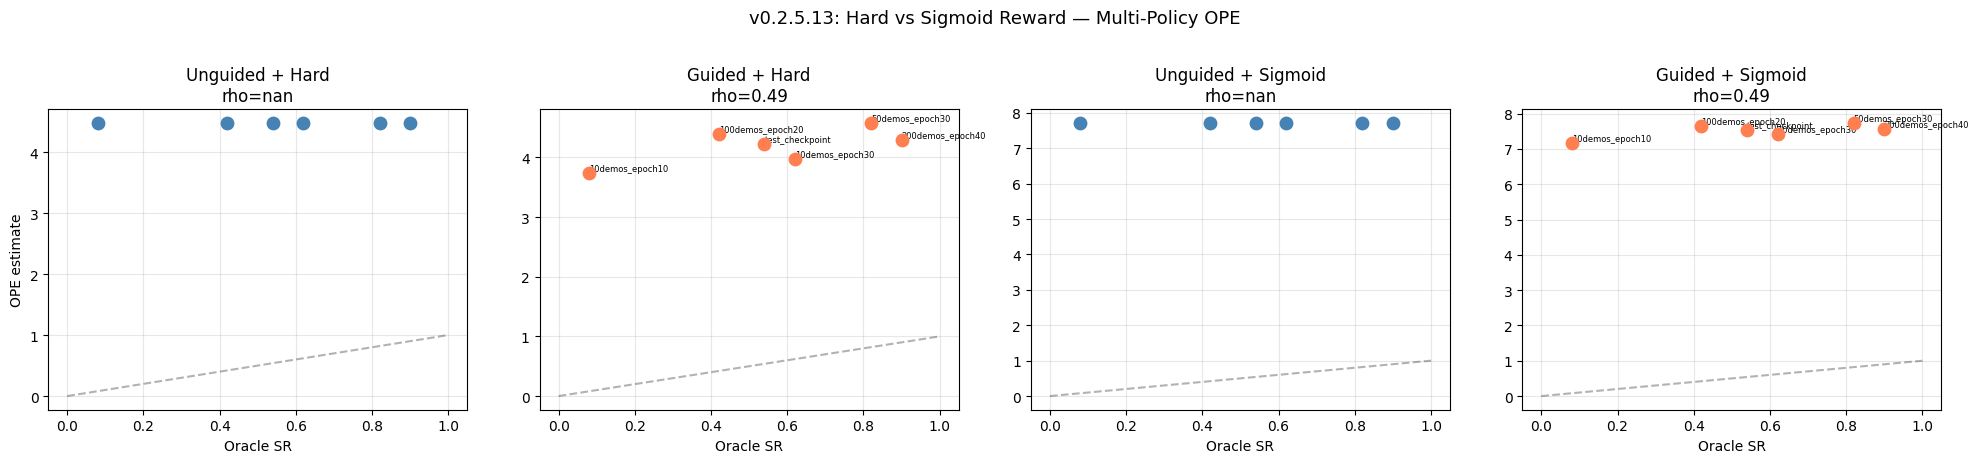

In [11]:
# ── Figure 1: Oracle vs OPE — Hard vs Sigmoid (4-panel) ──
fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))
names = [p["name"] for p in TARGET_POLICIES]

# Panel 1: Unguided hard
ax = axes[0]
ax.scatter(oracle_srs, unguided_opes_hard_list, c='steelblue', s=80, zorder=5)
ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)
ax.set_xlabel('Oracle SR')
ax.set_ylabel('OPE estimate')
ax.set_title(f'Unguided + Hard\nrho={rho_u_hard:.2f}')
ax.set_xlim(-0.05, 1.05)
ax.grid(True, alpha=0.3)

# Panel 2: Guided hard
ax = axes[1]
ax.scatter(oracle_srs, guided_opes_hard, c='coral', s=80, zorder=5)
for j, n in enumerate(names):
    ax.annotate(n, (oracle_srs[j], guided_opes_hard[j]), fontsize=6, ha='left', va='bottom')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)
ax.set_xlabel('Oracle SR')
ax.set_title(f'Guided + Hard\nrho={rho_g_hard:.2f}')
ax.set_xlim(-0.05, 1.05)
ax.grid(True, alpha=0.3)

# Panel 3: Unguided sigmoid
ax = axes[2]
ax.scatter(oracle_srs, [unguided_ope_sigmoid]*len(oracle_srs), c='steelblue', s=80, zorder=5)
ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)
ax.set_xlabel('Oracle SR')
ax.set_title(f'Unguided + Sigmoid\nrho={rho_u_sigm:.2f}')
ax.set_xlim(-0.05, 1.05)
ax.grid(True, alpha=0.3)

# Panel 4: Guided sigmoid (the key result)
ax = axes[3]
ax.scatter(oracle_srs, guided_opes_sigmoid, c='coral', s=80, zorder=5)
for j, n in enumerate(names):
    ax.annotate(n, (oracle_srs[j], guided_opes_sigmoid[j]), fontsize=6, ha='left', va='bottom')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)
ax.set_xlabel('Oracle SR')
ax.set_title(f'Guided + Sigmoid\nrho={rho_g_sigm:.2f}')
ax.set_xlim(-0.05, 1.05)
ax.grid(True, alpha=0.3)

fig.suptitle('v0.2.5.13: Hard vs Sigmoid Reward — Multi-Policy OPE', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

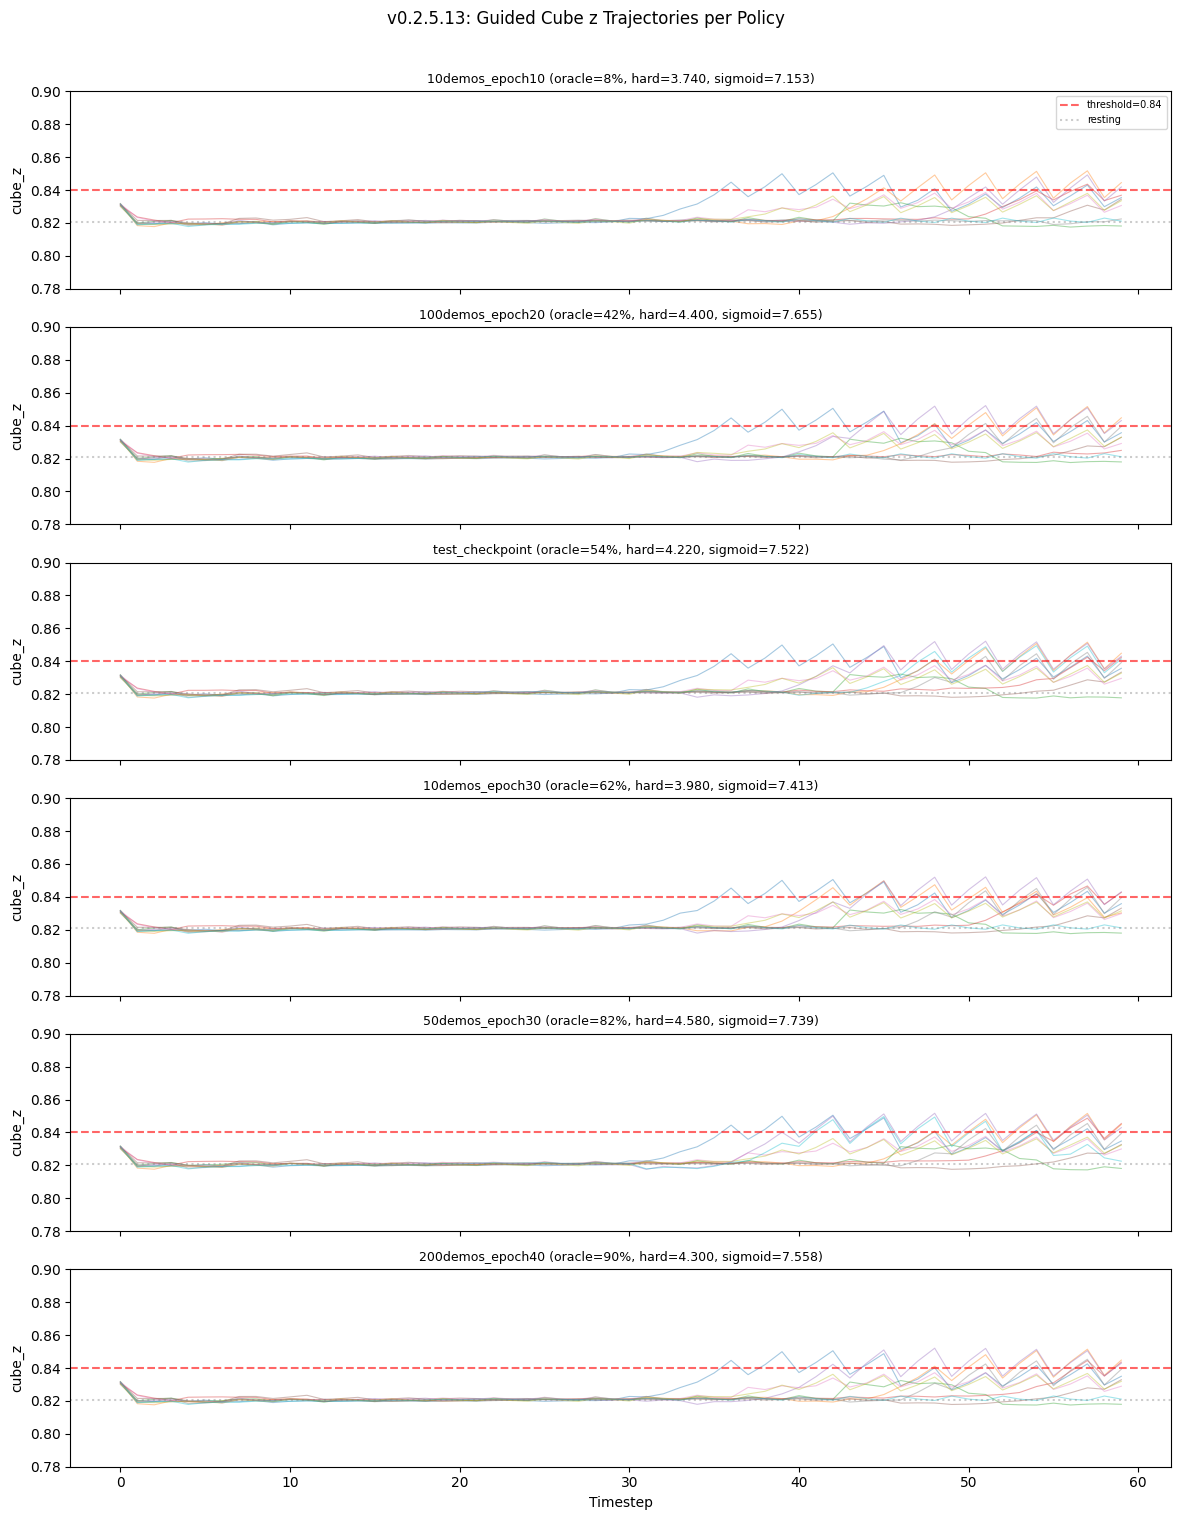

In [12]:
# ── Figure 2: Cube z trajectory grid (one row per policy, guided only) ──
n_policies = len(TARGET_POLICIES)
fig, axes = plt.subplots(n_policies, 1, figsize=(12, 2.5 * n_policies), sharex=True)

for i, pol in enumerate(TARGET_POLICIES):
    ax = axes[i]
    name = pol["name"]
    r = results[name]
    guided_states = r["guided_states"]
    
    # Plot cube_z for first 10 trajectories
    for j in range(min(10, guided_states.shape[0])):
        ax.plot(guided_states[j, :, CUBE_Z_INDEX], alpha=0.4, linewidth=0.8)
    
    ax.axhline(LIFT_THRESHOLD, color='red', linestyle='--', alpha=0.6, label=f'threshold={LIFT_THRESHOLD}')
    ax.axhline(0.8208, color='gray', linestyle=':', alpha=0.4, label='resting')
    ax.set_ylabel('cube_z')
    ax.set_title(f"{name} (oracle={r['oracle_sr']*100:.0f}%, "
                 f"hard={r['guided_ope_hard']:.3f}, sigmoid={r['guided_ope_sigmoid']:.3f})",
                 fontsize=9)
    ax.set_ylim(0.78, 0.90)
    if i == 0:
        ax.legend(fontsize=7, loc='upper right')

axes[-1].set_xlabel('Timestep')
fig.suptitle('v0.2.5.13: Guided Cube z Trajectories per Policy', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

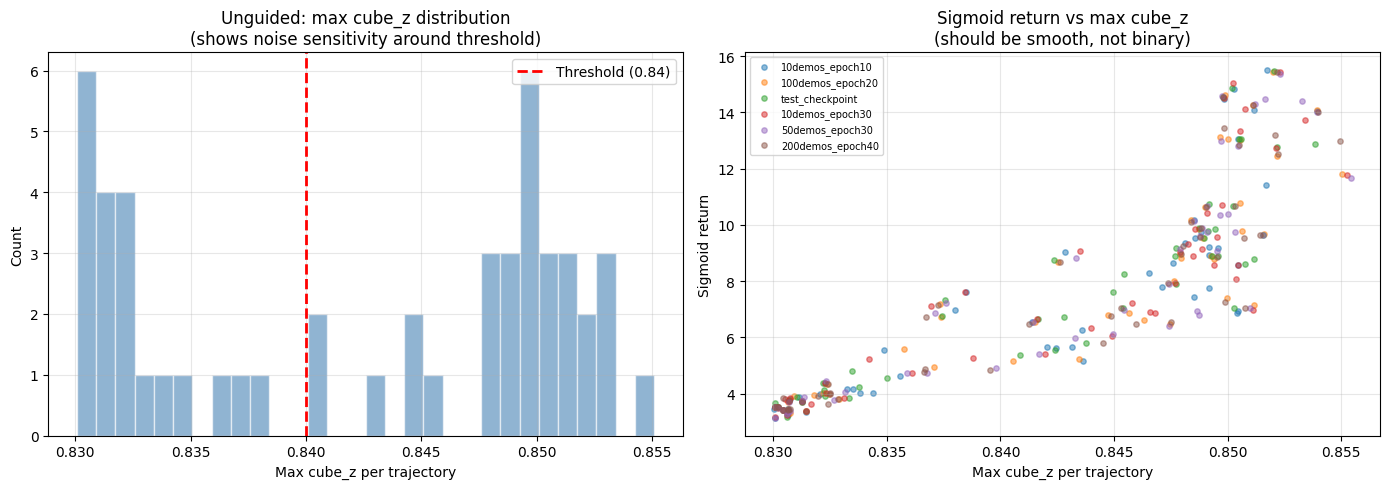

In [13]:
# ── Figure 3: Cube z max distribution — hard vs sigmoid sensitivity ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: Distribution of max cube_z per trajectory (unguided)
ax = axes[0]
cube_z_max = unguided_states[:, :, CUBE_Z_INDEX].max(axis=1)
ax.hist(cube_z_max, bins=30, alpha=0.6, color='steelblue', edgecolor='white')
ax.axvline(LIFT_THRESHOLD, color='red', linestyle='--', linewidth=2, label=f'Threshold ({LIFT_THRESHOLD})')
ax.set_xlabel('Max cube_z per trajectory')
ax.set_ylabel('Count')
ax.set_title('Unguided: max cube_z distribution\n(shows noise sensitivity around threshold)')
ax.legend()
ax.grid(True, alpha=0.3)

# Panel 2: Sigmoid return vs max cube_z (shows smooth vs binary scoring)
ax = axes[1]
for name in [p["name"] for p in TARGET_POLICIES]:
    r = results[name]
    czm = r["guided_states"][:, :, CUBE_Z_INDEX].max(axis=1)
    sr = r["guided_returns_sigmoid"]
    ax.scatter(czm, sr, s=15, alpha=0.5, label=name)
ax.set_xlabel('Max cube_z per trajectory')
ax.set_ylabel('Sigmoid return')
ax.set_title('Sigmoid return vs max cube_z\n(should be smooth, not binary)')
ax.legend(fontsize=7)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

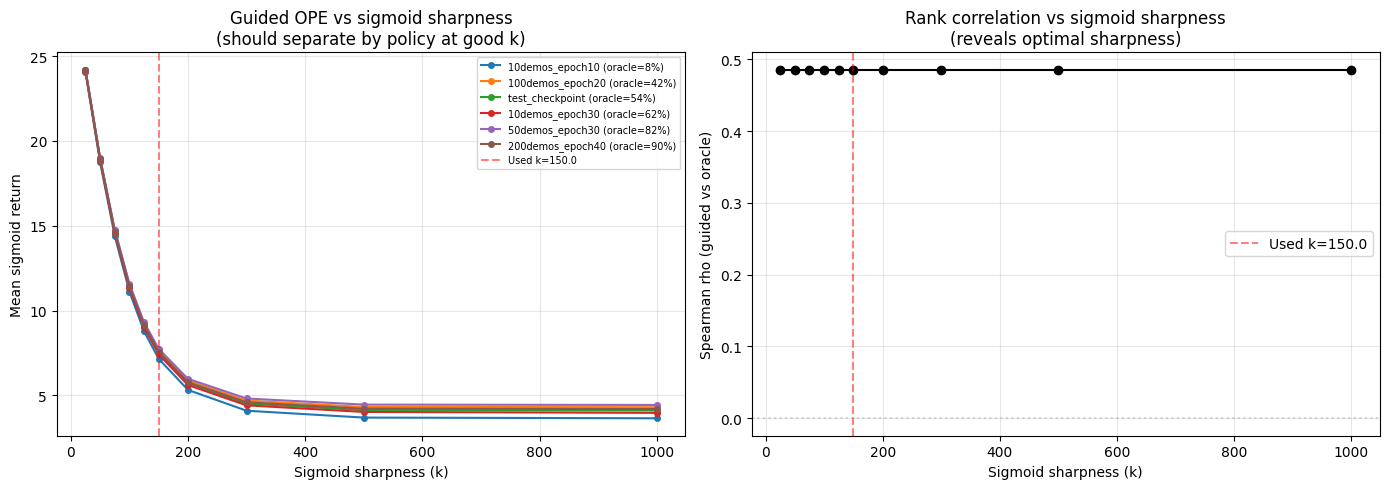

Best sharpness: k=25 (rho=0.4857)
Used sharpness: k=150.0 (rho=0.4857)


In [14]:
# ── Figure 4: Sigmoid sharpness sensitivity sweep (on unguided data) ──
# Shows how OPE estimate changes with different sharpness values
sharpness_values = [25, 50, 75, 100, 125, 150, 200, 300, 500, 1000]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# For each policy (guided), compute sigmoid OPE at various sharpness values
ax = axes[0]
for name in [p["name"] for p in TARGET_POLICIES]:
    r = results[name]
    opes = []
    for k in sharpness_values:
        cube_z = r["guided_states"][:, :, CUBE_Z_INDEX]
        rewards_k = sigmoid_reward(cube_z, sharpness=k)
        opes.append(rewards_k.sum(axis=1).mean())
    ax.plot(sharpness_values, opes, 'o-', markersize=4, label=f"{name} (oracle={r['oracle_sr']*100:.0f}%)")

ax.axvline(SIGMOID_SHARPNESS, color='red', linestyle='--', alpha=0.5, label=f'Used k={SIGMOID_SHARPNESS}')
ax.set_xlabel('Sigmoid sharpness (k)')
ax.set_ylabel('Mean sigmoid return')
ax.set_title('Guided OPE vs sigmoid sharpness\n(should separate by policy at good k)')
ax.legend(fontsize=7)
ax.grid(True, alpha=0.3)

# Spearman rho vs sharpness
ax = axes[1]
rho_vs_k = []
for k in sharpness_values:
    opes_k = []
    for name in [p["name"] for p in TARGET_POLICIES]:
        r = results[name]
        cube_z = r["guided_states"][:, :, CUBE_Z_INDEX]
        rewards_k = sigmoid_reward(cube_z, sharpness=k)
        opes_k.append(rewards_k.sum(axis=1).mean())
    rho_k, _ = stats.spearmanr(oracle_srs, opes_k)
    rho_vs_k.append(rho_k)

ax.plot(sharpness_values, rho_vs_k, 'ko-', markersize=6)
ax.axvline(SIGMOID_SHARPNESS, color='red', linestyle='--', alpha=0.5, label=f'Used k={SIGMOID_SHARPNESS}')
ax.axhline(0.0, color='gray', linestyle=':', alpha=0.3)
ax.set_xlabel('Sigmoid sharpness (k)')
ax.set_ylabel('Spearman rho (guided vs oracle)')
ax.set_title('Rank correlation vs sigmoid sharpness\n(reveals optimal sharpness)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

best_k_idx = np.argmax(rho_vs_k)
print(f"Best sharpness: k={sharpness_values[best_k_idx]} (rho={rho_vs_k[best_k_idx]:.4f})")
print(f"Used sharpness: k={SIGMOID_SHARPNESS} (rho={rho_vs_k[sharpness_values.index(SIGMOID_SHARPNESS)]:.4f})")